### Compare the performance of different clustering methods using EW investment vs. CSI 141 benchmark, and obtain the clustered stock lists by year (2020-2024).

In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import random
import csv
import warnings
warnings.filterwarnings('ignore')


class ChameleonClustering:
    """Chameleon聚类算法"""
    def __init__(self, k_initial=25, final_clusters=6, alpha=2.0, beta=1.2, gamma=0.8):
        self.k_initial = k_initial  # 增加初始聚类数
        self.final_clusters = final_clusters  # 增加最终聚类数
        self.alpha = alpha  # 提高相对互连性权重
        self.beta = beta  # 提高相对近似性权重
        self.gamma = gamma  # 新增聚类质量权重
        self.labels_ = None
        
    def fit_predict(self, X):
        """Chameleon聚类主要方法"""
        
        n_samples, n_features = X.shape
        
        # 创建更多的初始小聚类
        initial_k = min(self.k_initial, max(5, n_samples // 15))  # 增加初始聚类数
        if initial_k < 2:
            self.labels_ = np.zeros(n_samples, dtype=int)
            return self.labels_
            
        # 多次运行选择最佳初始聚类
        best_kmeans = None
        best_inertia = float('inf')
        
        for _ in range(5):
            kmeans = KMeans(n_clusters=initial_k, random_state=None, n_init=15)
            initial_labels = kmeans.fit_predict(X)
            if kmeans.inertia_ < best_inertia:
                best_inertia = kmeans.inertia_
                best_kmeans = kmeans
        
        initial_labels = best_kmeans.labels_
        cluster_centers = best_kmeans.cluster_centers_
        similarity_matrix = self._compute_advanced_similarity(X, initial_labels, cluster_centers, initial_k)

        final_labels = self._intelligent_merge_clusters(X, initial_labels, similarity_matrix, initial_k)
        
        self.labels_ = final_labels
        return self.labels_
    
    def _compute_advanced_similarity(self, X, labels, centers, n_clusters):
        """聚类间相似性计算"""
        similarity_matrix = np.zeros((n_clusters, n_clusters))
        
        # 预计算每个聚类的统计信息
        cluster_stats = {}
        for i in range(n_clusters):
            cluster_points = X[labels == i]
            cluster_stats[i] = {
                'points': cluster_points,
                'center': centers[i],
                'size': len(cluster_points),
                'compactness': self._compute_advanced_compactness(cluster_points, centers[i]),
                'density': len(cluster_points) / (np.std(cluster_points, axis=0).sum())
            }
        
        for i in range(n_clusters):
            for j in range(i + 1, n_clusters):
                if i not in cluster_stats or j not in cluster_stats:
                    continue
                
                stats_i = cluster_stats[i]
                stats_j = cluster_stats[j]
                
                # 1.  相对近似性
                center_distance = np.linalg.norm(stats_i['center'] - stats_j['center'])
                avg_compactness = (stats_i['compactness'] + stats_j['compactness']) / 2
                
                if avg_compactness > 0:
                    relative_closeness = center_distance / avg_compactness
                else:
                    relative_closeness = center_distance + 1
                
                # 2. 相对互连
                relative_interconnectivity = self._compute_advanced_interconnectivity(
                    stats_i['points'], stats_j['points'], stats_i['center'], stats_j['center'])
                
                # 3. 聚类大小和密度兼容性
                size_compatibility = self._compute_size_compatibility(stats_i['size'], stats_j['size'])
                density_compatibility = self._compute_density_compatibility(stats_i['density'], stats_j['density'])

                shape_compatibility = self._compute_shape_compatibility(stats_i['points'], stats_j['points'])
                
                connectivity_score = relative_interconnectivity * self.alpha
                closeness_score = 1.0 / (relative_closeness * self.beta)
                compatibility_score = (size_compatibility + density_compatibility + shape_compatibility) / 3 * self.gamma
                
                similarity = connectivity_score + closeness_score + compatibility_score
                
                similarity_matrix[i, j] = similarity
                similarity_matrix[j, i] = similarity
        
        return similarity_matrix
    
    def _compute_advanced_compactness(self, cluster_points, center):
        """计算聚类紧密度"""
        if len(cluster_points) <= 1:
            return 1.0
        
        # 使用加权距离和方差
        distances = [np.linalg.norm(point - center) for point in cluster_points]
        mean_distance = np.mean(distances)
        distance_variance = np.var(distances)

        compactness = mean_distance + np.sqrt(distance_variance)
        return compactness
    
    def _compute_advanced_interconnectivity(self, cluster_i, cluster_j, center_i, center_j):
        """互连性计算"""
        if len(cluster_i) == 0 or len(cluster_j) == 0:
            return 0
        

        boundary_ratio = 0.4  # 增加边界点比例
        k_i = max(1, int(len(cluster_i) * boundary_ratio))
        k_j = max(1, int(len(cluster_j) * boundary_ratio))
        
        distances_i_to_j = [np.linalg.norm(point - center_j) for point in cluster_i]
        distances_j_to_i = [np.linalg.norm(point - center_i) for point in cluster_j]
        
        closest_i_indices = np.argsort(distances_i_to_j)[:k_i]
        closest_j_indices = np.argsort(distances_j_to_i)[:k_j]
        
        # 计算多层次互连强度
        interconnect_strength = 0
        count = 0
        
        # 最近邻互连
        for i_idx in closest_i_indices:
            for j_idx in closest_j_indices:
                dist = np.linalg.norm(cluster_i[i_idx] - cluster_j[j_idx])
                interconnect_strength += 1.0 / dist
                count += 1
        
        # 中心点互连
        center_interconnect = 1.0 / np.linalg.norm(center_i - center_j)
        interconnect_strength += center_interconnect * 2  # 给中心互连更高权重
        count += 1
        
        return interconnect_strength / count if count > 0 else 0
    
    def _compute_size_compatibility(self, size_i, size_j):
        """计算聚类大小兼容性"""
        return min(size_i, size_j) / max(size_i, size_j)
    
    def _compute_density_compatibility(self, density_i, density_j):
        """计算聚类密度兼容性"""
        return min(density_i, density_j) / max(density_i, density_j)
    
    def _compute_shape_compatibility(self, cluster_i, cluster_j):
        """计算聚类形状兼容性"""
        if len(cluster_i) <= 1 or len(cluster_j) <= 1:
            return 0.5

        try:
            cov_i = np.cov(cluster_i.T)
            cov_j = np.cov(cluster_j.T)
            
            # 使用Frobenius范数计算协方差矩阵差异
            cov_diff = np.linalg.norm(cov_i - cov_j, 'fro')
            cov_avg = (np.linalg.norm(cov_i, 'fro') + np.linalg.norm(cov_j, 'fro')) / 2
            
            if cov_avg > 0:
                shape_similarity = 1.0 / (1.0 + cov_diff / cov_avg)
            else:
                shape_similarity = 0.5
        except:
            shape_similarity = 0.5
        
        return shape_similarity
    
    def _intelligent_merge_clusters(self, X, initial_labels, similarity_matrix, n_initial_clusters):
        """聚类合并策略"""
        current_clusters = list(range(n_initial_clusters))
        cluster_mapping = {i: i for i in range(n_initial_clusters)}

        cluster_quality = {}
        for cluster_id in current_clusters:
            cluster_points = X[initial_labels == cluster_id]
            center = np.mean(cluster_points, axis=0)
            distances = [np.linalg.norm(point - center) for point in cluster_points]
            compactness = 1.0 / (np.mean(distances))
            size_score = min(len(cluster_points) / 20.0, 1.0)
            cluster_quality[cluster_id] = compactness * size_score
        

        while len(current_clusters) > self.final_clusters:
            max_score = -1
            merge_pair = None
            
            for i in range(len(current_clusters)):
                for j in range(i + 1, len(current_clusters)):
                    cluster_i = current_clusters[i]
                    cluster_j = current_clusters[j]
                    
                    # 检查合并后的聚类大小
                    size_i = np.sum(initial_labels == cluster_i)
                    size_j = np.sum(initial_labels == cluster_j)
                    merged_size = size_i + size_j

                    if merged_size > len(initial_labels) * 0.35:
                        continue

                    similarity = similarity_matrix[cluster_i, cluster_j]
                    quality_match = min(cluster_quality.get(cluster_i, 0), cluster_quality.get(cluster_j, 0))
                    size_preference = 1.0 - abs(size_i - size_j) / max(size_i, size_j) 
                    
                    combined_score = similarity * 0.6 + quality_match * 0.25 + size_preference * 0.15
                    
                    if combined_score > max_score:
                        max_score = combined_score
                        merge_pair = (i, j, cluster_i, cluster_j)
            
            if merge_pair is None or max_score <= 0:
                break
            
            # 执行合并
            i, j, cluster_i, cluster_j = merge_pair
            
            # 更新聚类映射和质量
            for old_cluster, current_cluster in cluster_mapping.items():
                if current_cluster == cluster_j:
                    cluster_mapping[old_cluster] = cluster_i
            
            # 更新聚类质量
            merged_points = X[np.isin(initial_labels, [cluster_i, cluster_j])]
            if len(merged_points) > 0:
                center = np.mean(merged_points, axis=0)
                distances = [np.linalg.norm(point - center) for point in merged_points]
                compactness = 1.0 / (np.mean(distances))
                size_score = min(len(merged_points) / 20.0, 1.0)
                cluster_quality[cluster_i] = compactness * size_score
            
            current_clusters.remove(cluster_j)

            for k in range(n_initial_clusters):
                if k != cluster_i and k != cluster_j and k in current_clusters:
                    weight_i = cluster_quality.get(cluster_i, 1)
                    weight_j = cluster_quality.get(cluster_j, 1)
                    total_weight = weight_i + weight_j
                    
                    if total_weight > 0:
                        new_similarity = (similarity_matrix[cluster_i, k] * weight_i + 
                                        similarity_matrix[cluster_j, k] * weight_j) / total_weight
                    else:
                        new_similarity = (similarity_matrix[cluster_i, k] + similarity_matrix[cluster_j, k]) / 2
                    
                    similarity_matrix[cluster_i, k] = new_similarity
                    similarity_matrix[k, cluster_i] = new_similarity
        
        final_labels = np.zeros_like(initial_labels)
        cluster_id_mapping = {old_id: new_id for new_id, old_id in enumerate(current_clusters)}
        
        for i, initial_label in enumerate(initial_labels):
            mapped_cluster = cluster_mapping[initial_label]
            final_labels[i] = cluster_id_mapping.get(mapped_cluster, 0)
        
        return final_labels

class OptimizedSTINGClustering:
    """STING聚类算法"""
    def __init__(self, grid_levels=3, density_threshold=0.08, min_cluster_size=8, confidence_threshold=0.90):
        self.grid_levels = grid_levels  # 多层次网格结构
        self.density_threshold = density_threshold  # 提高密度阈值
        self.min_cluster_size = min_cluster_size  # 合理的最小聚类大小
        self.confidence_threshold = confidence_threshold  # 统计置信度阈值
        self.labels_ = None
        
    def fit_predict(self, X):
        """STING聚类主要方法"""
        n_samples, n_features = X.shape
        hierarchical_grids = self._build_hierarchical_grids(X)
        grid_stats = self._calculate_grid_statistics(X, hierarchical_grids)
        quality_grids = self._identify_quality_grids(grid_stats, n_samples)
        labels = self._form_clusters_optimized(X, quality_grids, grid_stats)
        labels = self._post_process_clusters_optimized(X, labels)
        self.labels_ = labels
        return self.labels_
    
    def _build_hierarchical_grids(self, X):
        """构建多层次网格结构"""
        hierarchical_grids = {}

        min_vals = X.min(axis=0)
        max_vals = X.max(axis=0)
        ranges = max_vals - min_vals
        
        # 防止除零
        ranges = np.where(ranges == 0, 1.0, ranges)
        
        for level in range(self.grid_levels):
            # 网格密度随层次递增：4, 6, 8
            grid_size = 4 + level * 2
            grid_intervals = ranges / grid_size
            
            hierarchical_grids[level] = {
                'grid_size': grid_size,
                'grid_intervals': grid_intervals,
                'min_vals': min_vals,
                'max_vals': max_vals
            }
        
        return hierarchical_grids
    
    def _calculate_grid_statistics(self, X, hierarchical_grids):
        """计算多层次网格统计信息"""
        all_grid_stats = {}
        
        for level, grid_info in hierarchical_grids.items():
            grid_size = grid_info['grid_size']
            grid_intervals = grid_info['grid_intervals']
            min_vals = grid_info['min_vals']

            grid_assignment = np.floor((X - min_vals) / grid_intervals).astype(int)
            grid_assignment = np.clip(grid_assignment, 0, grid_size - 1)

            grid_stats = {}
            point_to_grid = {}
            
            for i, grid_coord in enumerate(grid_assignment):
                grid_key = tuple(grid_coord)
                if grid_key not in grid_stats:
                    grid_stats[grid_key] = {
                        'count': 0, 
                        'points': [], 
                        'sum': np.zeros(X.shape[1]),
                        'sum_sq': np.zeros(X.shape[1])
                    }
                
                grid_stats[grid_key]['count'] += 1
                grid_stats[grid_key]['points'].append(i)
                grid_stats[grid_key]['sum'] += X[i]
                grid_stats[grid_key]['sum_sq'] += X[i] ** 2
                point_to_grid[i] = grid_key

            for grid_key, stats in grid_stats.items():
                if stats['count'] > 0:
                    # 均值
                    stats['mean'] = stats['sum'] / stats['count']
                    # 方差
                    if stats['count'] > 1:
                        stats['variance'] = (stats['sum_sq'] - stats['sum']**2 / stats['count']) / (stats['count'] - 1)
                    else:
                        stats['variance'] = np.zeros(X.shape[1])
                    # 密度 (相对于总样本)
                    stats['density'] = stats['count'] / len(X)
                    # 紧密度 (方差的倒数)
                    stats['compactness'] = 1.0 / np.mean(stats['variance'])
                    # 质量评分
                    stats['quality'] = stats['density'] * stats['compactness']
            
            all_grid_stats[level] = {
                'grids': grid_stats,
                'point_mapping': point_to_grid,
                'grid_size': grid_size
            }
        
        return all_grid_stats
    
    def _identify_quality_grids(self, all_grid_stats, n_samples):
        """识别高质量网格区域"""
        quality_grids = set()
        adaptive_density_threshold = max(self.density_threshold, 3.0 / n_samples)

        all_candidates = []
        
        for level, level_stats in all_grid_stats.items():
            grids = level_stats['grids']
            
            for grid_key, stats in grids.items():
                if (stats['count'] >= self.min_cluster_size and 
                    stats['density'] >= adaptive_density_threshold):

                    size_preference = min(stats['count'] / 20.0, 1.0)
                    comprehensive_score = (stats['density'] * 0.4 + 
                                         stats['compactness'] * 0.3 + 
                                         size_preference * 0.3)
                    
                    all_candidates.append({
                        'level': level,
                        'grid_key': grid_key,
                        'stats': stats,
                        'score': comprehensive_score
                    })

        if len(all_candidates) > 0:
            all_candidates.sort(key=lambda x: x['score'], reverse=True)

            selected_points = set()
            
            for candidate in all_candidates:
                candidate_points = set(candidate['stats']['points'])
                overlap_ratio = len(candidate_points & selected_points) / len(candidate_points)
                
                if overlap_ratio < 0.3:
                    quality_grids.add((candidate['level'], candidate['grid_key']))
                    selected_points.update(candidate_points)

                if len(quality_grids) >= 6:
                    break
        
        if len(quality_grids) == 0:
            for level, level_stats in all_grid_stats.items():
                grids = level_stats['grids']

                grid_list = [(k, v) for k, v in grids.items() if v['count'] >= max(3, self.min_cluster_size // 2)]
                grid_list.sort(key=lambda x: x[1]['count'], reverse=True)
                
                for grid_key, stats in grid_list[:3]:
                    quality_grids.add((level, grid_key))
                
                if len(quality_grids) >= 3:
                    break
        return quality_grids
    
    def _form_clusters_optimized(self, X, quality_grids, all_grid_stats):
        """聚类形成过程"""
        n_samples = len(X)
        labels = np.full(n_samples, -1, dtype=int)  # 初始化为噪声点
        
        if len(quality_grids) == 0:
            return labels
        
        current_cluster_id = 0
        
        # 为每个高质量网格区域分配聚类标签
        for level, grid_key in quality_grids:
            level_stats = all_grid_stats[level]
            
            if grid_key in level_stats['grids']:
                grid_stats = level_stats['grids'][grid_key]
                point_indices = grid_stats['points']
                
                # 检查邻近网格，形成连通聚类
                connected_points = self._find_connected_region(
                    level, grid_key, all_grid_stats, set())
                
                if len(connected_points) >= self.min_cluster_size:
                    for point_idx in connected_points:
                        if labels[point_idx] == -1:  # 只分配未分配的点
                            labels[point_idx] = current_cluster_id
                    current_cluster_id += 1
        
        return labels
    
    def _find_connected_region(self, start_level, start_grid, all_grid_stats, visited):
        """查找连通区域"""
        connected_points = set()
        stack = [(start_level, start_grid)]
        level_visited = {start_level: set()}
        
        while stack:
            level, grid_key = stack.pop()
            
            if level in level_visited and grid_key in level_visited[level]:
                continue
            
            if level not in level_visited:
                level_visited[level] = set()
            level_visited[level].add(grid_key)
            
            if level in all_grid_stats and grid_key in all_grid_stats[level]['grids']:
                grid_stats = all_grid_stats[level]['grids'][grid_key]
                
                # 检查网格质量
                if (grid_stats['count'] >= max(3, self.min_cluster_size // 3) and 
                    grid_stats['density'] >= self.density_threshold * 0.5):
                    
                    connected_points.update(grid_stats['points'])
                    
                    # 查找相邻网格
                    neighbors = self._get_grid_neighbors(grid_key, all_grid_stats[level]['grid_size'])
                    for neighbor in neighbors:
                        if neighbor not in level_visited[level]:
                            stack.append((level, neighbor))
        
        return connected_points
    
    def _get_grid_neighbors(self, grid_key, grid_size):
        """获取网格邻居"""
        neighbors = []
        x, y = grid_key

        directions = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
        
        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if 0 <= nx < grid_size and 0 <= ny < grid_size:
                neighbors.append((nx, ny))
        
        return neighbors
    
    def _post_process_clusters_optimized(self, X, labels):
        """后处理"""
        unique_labels = set(labels)
        if -1 in unique_labels:
            unique_labels.remove(-1)
        
        if len(unique_labels) == 0:
            return labels

        cluster_sizes = {}
        for label in unique_labels:
            cluster_sizes[label] = np.sum(labels == label)

        small_clusters = [label for label, size in cluster_sizes.items() 
                         if size < self.min_cluster_size]
        large_clusters = [label for label, size in cluster_sizes.items() 
                         if size >= self.min_cluster_size]
        
        if len(large_clusters) > 0:
            for small_cluster in small_clusters:
                small_indices = np.where(labels == small_cluster)[0]
                small_points = X[small_indices]
                small_center = np.mean(small_points, axis=0)
                min_distance = float('inf')
                nearest_large_cluster = large_clusters[0]
                
                for large_cluster in large_clusters:
                    large_indices = np.where(labels == large_cluster)[0]
                    large_points = X[large_indices]
                    large_center = np.mean(large_points, axis=0)
                    
                    distance = np.linalg.norm(small_center - large_center)
                    if distance < min_distance:
                        min_distance = distance
                        nearest_large_cluster = large_cluster

                labels[small_indices] = nearest_large_cluster

        noise_indices = np.where(labels == -1)[0]
        if len(noise_indices) > 0 and len(unique_labels) > 0:

            for noise_idx in noise_indices:
                noise_point = X[noise_idx]
                min_distance = float('inf')
                nearest_cluster = list(unique_labels)[0]
                
                for cluster_label in unique_labels:
                    cluster_indices = np.where(labels == cluster_label)[0]
                    if len(cluster_indices) > 0:
                        cluster_points = X[cluster_indices]
                        cluster_center = np.mean(cluster_points, axis=0)
                        distance = np.linalg.norm(noise_point - cluster_center)
                        
                        if distance < min_distance:
                            min_distance = distance
                            nearest_cluster = cluster_label
                
                labels[noise_idx] = nearest_cluster
        final_labels = np.full_like(labels, -1)
        new_label = 0
        
        for old_label in sorted(set(labels)):
            if old_label != -1:
                final_labels[labels == old_label] = new_label
                new_label += 1

        final_unique = set(final_labels)
        if -1 in final_unique:
            final_unique.remove(-1)
        
        final_sizes = {}
        for label in final_unique:
            final_sizes[label] = np.sum(final_labels == label)

        return final_labels


class ImprovedDBSCAN:
    """DBSCAN聚类算法"""
    def __init__(self, eps=0.3, min_samples=8):
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None
    
    def fit_predict(self, X):
        """ DBSCAN聚类方法"""
        n_samples = X.shape[0]
        optimal_eps = self._estimate_optimal_eps(X)
        adaptive_min_samples = max(4, min(self.min_samples, n_samples // 20))
        dbscan = DBSCAN(eps=optimal_eps, min_samples=adaptive_min_samples, metric='euclidean')
        self.labels_ = dbscan.fit_predict(X)
        self.labels_ = self._post_process_clusters(X, self.labels_)
        
        return self.labels_
    
    def _estimate_optimal_eps(self, X):
        """使用k-distance图估计最优eps值"""
        n_samples = X.shape[0]
        k = min(8, n_samples // 10)
        nbrs = NearestNeighbors(n_neighbors=k)
        nbrs.fit(X)
        distances, indices = nbrs.kneighbors(X)
        
        # 取第k个邻居的距离并排序
        k_distances = distances[:, k-1]
        k_distances = np.sort(k_distances)[::-1]
        if len(k_distances) > 10:
            # 计算二阶差分
            first_diff = np.diff(k_distances)
            second_diff = np.diff(first_diff)
            
            # 找到二阶差分最大的点
            if len(second_diff) > 0:
                elbow_idx = np.argmax(second_diff) + 2
                optimal_eps = k_distances[min(elbow_idx, len(k_distances) - 1)]
            else:
                optimal_eps = np.percentile(k_distances, 85)
        else:
            optimal_eps = np.mean(k_distances)
        optimal_eps = max(0.1, min(optimal_eps, 0.8))
        
        return optimal_eps
    
    def _post_process_clusters(self, X, labels):
        """后处理聚类结果"""
        unique_labels = set(labels)
        if -1 in unique_labels:
            unique_labels.remove(-1)
        
        if len(unique_labels) <= 1:
            return labels

        cluster_sizes = {}
        for label in unique_labels:
            cluster_sizes[label] = np.sum(labels == label)
        min_cluster_size = 5
        small_clusters = [label for label, size in cluster_sizes.items() if size < min_cluster_size]
        large_clusters = [label for label, size in cluster_sizes.items() if size >= min_cluster_size]
        
        if not large_clusters:
            return labels
        new_labels = labels.copy()
        
        for small_cluster in small_clusters:
            small_cluster_points = X[labels == small_cluster]
            small_cluster_indices = np.where(labels == small_cluster)[0]

            small_center = np.mean(small_cluster_points, axis=0)

            min_distance = float('inf')
            nearest_large_cluster = large_clusters[0]
            
            for large_cluster in large_clusters:
                large_cluster_points = X[labels == large_cluster]
                large_center = np.mean(large_cluster_points, axis=0)
                distance = np.linalg.norm(small_center - large_center)
                
                if distance < min_distance:
                    min_distance = distance
                    nearest_large_cluster = large_cluster
            
            # 重新分配标签
            new_labels[small_cluster_indices] = nearest_large_cluster
        
        return new_labels

class StockClusteringPipeline:
    def __init__(self):
        self.stock_data = None
        self.results = {}
        
    def load_data(self):
        """加载数据文件并根据上市日期筛选股票"""

        # 加载两个股票价格数据文件
        data1 = pd.read_csv('TRD_Dalyr(20150105-20200103).csv')
        data2 = pd.read_csv('TRD_Dalyr(20200106-20241213).csv')
        
        # 合并股票价格数据
        self.stock_data = pd.concat([data1, data2], ignore_index=True)
        
        # 数据预处理
        self.stock_data['Trddt'] = pd.to_datetime(self.stock_data['Trddt'])
        self.stock_data['Year'] = self.stock_data['Trddt'].dt.year
        fi_data = pd.read_excel('FI(季频).xlsx')
        
        # 处理listingDate列，提取年份
        fi_data['listingDate'] = pd.to_datetime(fi_data['listingDate'], errors='coerce')
        fi_data['listingYear'] = fi_data['listingDate'].dt.year
        
        # 筛选上市年份<=2014的股票
        valid_stocks = fi_data[fi_data['listingYear'] <= 2014]

        valid_stock_codes = valid_stocks.iloc[:, 0].dropna().unique()
        
        self.stock_data = self.stock_data[self.stock_data['Stkcd'].isin(valid_stock_codes)]
        return self.stock_data,valid_stock_codes
        
    def remove_outliers_iqr(self, data):
        """使用箱线图方法(IQR)剔除异常值"""
        
        values = np.array(data)
        
        # 计算四分位数
        Q1 = np.percentile(values, 25)  # 下四分位数
        Q2 = np.percentile(values, 50)  # 中位数
        Q3 = np.percentile(values, 75)  # 上四分位数
        
        # 计算四分位差
        IQR = Q3 - Q1
        
        # 计算上须和下须
        upper_fence = Q3 + 1.5 * IQR  # 上须
        lower_fence = Q1 - 1.5 * IQR  # 下须
        
        # 识别异常值
        outlier_mask = (values > upper_fence) | (values < lower_fence)
        normal_mask = ~outlier_mask
        return normal_mask, outlier_mask

    def calculate_stock_metrics_for_year(self, year):
        """计算指定年份的股票指标用于聚类"""
        # 获取指定年份的数据
        year_data = self.stock_data[self.stock_data['Year'] == year]
        
        metrics = {}
        stock_codes = year_data['Stkcd'].unique()
        
        for stock_code in stock_codes:
            stock_data = year_data[year_data['Stkcd'] == stock_code].copy()
            stock_data = stock_data.sort_values('Trddt')

            # 计算日收益率
            stock_data['daily_return'] = stock_data['Clsprc'].pct_change()
            daily_returns = stock_data['daily_return'].dropna()
            
            # 年化收益率
            total_days = len(stock_data)
            annual_return = (stock_data['Clsprc'].iloc[-1] / stock_data['Clsprc'].iloc[0]) ** (252/total_days) - 1
            
            # 年化波动率
            annual_volatility = daily_returns.std() * np.sqrt(252)
            
            if annual_volatility == 0 or np.isnan(annual_return) or np.isnan(annual_volatility):
                continue
                
            metrics[stock_code] = {
                'annual_return': annual_return,
                'annual_volatility': annual_volatility
            }

        # 异常值处理
        # 提取所有股票的收益率和波动率
        stock_codes_list = list(metrics.keys())
        returns = [metrics[code]['annual_return'] for code in stock_codes_list]
        volatilities = [metrics[code]['annual_volatility'] for code in stock_codes_list]
        
        # 对年化收益率进行异常值检测
        return_normal_mask, return_outlier_mask = self.remove_outliers_iqr(returns)
        
        # 对年化波动率进行异常值检测
        vol_normal_mask, vol_outlier_mask = self.remove_outliers_iqr(volatilities)
        
        # 只保留在两个维度上都不是异常值的股票
        combined_normal_mask = return_normal_mask & vol_normal_mask
        
        # 更新metrics，只保留正常值
        filtered_metrics = {}
        removed_stocks = []
        
        for i, stock_code in enumerate(stock_codes_list):
            if combined_normal_mask[i]:
                filtered_metrics[stock_code] = metrics[stock_code]
            else:
                removed_stocks.append({
                    'code': stock_code,
                    'return': returns[i],
                    'volatility': volatilities[i],
                    'return_outlier': return_outlier_mask[i],
                    'vol_outlier': vol_outlier_mask[i]
                })
        
        print(f"  处理异常值后的股票数量: {len(filtered_metrics)}")
        metrics = filtered_metrics
    
        return metrics
    
    def calculate_cluster_sharpe_ratio(self, features, indices, risk_free_rate=0.03):
        """计算聚类的夏普比率"""
        if len(indices) == 0:
            return -np.inf
            
        individual_sharpes = []
        for idx in indices:
            stock_return = features[idx, 0]
            stock_volatility = features[idx, 1]
            if stock_volatility > 0:
                sharpe = (stock_return - risk_free_rate) / stock_volatility
                individual_sharpes.append(sharpe)
        
        if len(individual_sharpes) == 0:
            return -np.inf
        
        return np.mean(individual_sharpes)
    
    def find_optimal_params_by_sharpe_with_validation(self, train_features_scaled, train_features, 
                                                    val_features_scaled, val_features, val_stock_codes, 
                                                    method='kmeans', min_stocks=15):
        """基于夏普比率找到最优参数"""
        best_score = -np.inf
        best_params = None
        best_labels = None

        if method == 'kmeans':
            for n_clusters in range(2, min(11, len(train_features_scaled) // 20 + 1)):
                clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
                train_labels = clusterer.fit_predict(train_features_scaled)

                val_labels = clusterer.predict(val_features_scaled)
                val_clusters = {}
                for i, label in enumerate(val_labels):
                    if label not in val_clusters:
                        val_clusters[label] = []
                    val_clusters[label].append(i)
                
                best_cluster_sharpe = -np.inf
                best_cluster_size = 0
                for cluster_id, indices in val_clusters.items():
                    if len(indices) >= min_stocks:
                        sharpe = self.calculate_cluster_sharpe_ratio(val_features, indices)
                        if sharpe > best_cluster_sharpe:
                            best_cluster_sharpe = sharpe
                            best_cluster_size = len(indices)
                
                if best_cluster_sharpe > best_score and best_cluster_size >= min_stocks:
                    best_score = best_cluster_sharpe
                    best_params = {'n_clusters': n_clusters}
                    best_labels = val_labels 

        
        elif method == 'gmm':
            for n_components in range(2, min(6, len(train_features_scaled) // 20 + 1)):
                for covariance_type in ['full', 'tied', 'diag', 'spherical']:
                    clusterer = GaussianMixture(
                        n_components=n_components, 
                        covariance_type=covariance_type,
                        random_state=77777,
                        max_iter=160,
                        n_init=3
                    )
                    clusterer.fit(train_features_scaled)
                    val_labels = clusterer.predict(val_features_scaled)

                    val_clusters = {}
                    for i, label in enumerate(val_labels):
                        if label not in val_clusters:
                            val_clusters[label] = []
                        val_clusters[label].append(i)
                    
                    best_cluster_sharpe = -np.inf
                    best_cluster_size = 0
                    for cluster_id, indices in val_clusters.items():
                        if len(indices) >= min_stocks:
                            sharpe = self.calculate_cluster_sharpe_ratio(val_features, indices)
                            if sharpe > best_cluster_sharpe:
                                best_cluster_sharpe = sharpe
                                best_cluster_size = len(indices)
                    
                    if best_cluster_sharpe > best_score and best_cluster_size >= min_stocks:
                        best_score = best_cluster_sharpe
                        best_params = {'n_components': n_components, 'covariance_type': covariance_type}
                        best_labels = val_labels

        
        elif method == 'dbscan':
            eps_values = [1] 
            min_samples_values = [4,5,6,7] 
            
            for eps in eps_values:
                for min_samples in min_samples_values:
                    train_improved_dbscan = ImprovedDBSCAN(eps=eps, min_samples=min_samples)
                    train_labels = train_improved_dbscan.fit_predict(train_features_scaled)

                    val_improved_dbscan = ImprovedDBSCAN(eps=eps, min_samples=min_samples)
                    val_labels = val_improved_dbscan.fit_predict(val_features_scaled)

                    n_clusters = len(set(val_labels)) - (1 if -1 in val_labels else 0)
                    if n_clusters < 2:
                        continue
                    

                    val_clusters = {}
                    for i, label in enumerate(val_labels):
                        if label != -1: 
                            if label not in val_clusters:
                                val_clusters[label] = []
                            val_clusters[label].append(i)
                    
                    best_cluster_sharpe = -np.inf
                    best_cluster_size = 0
                    for cluster_id, indices in val_clusters.items():
                        if len(indices) >= min_stocks:
                            sharpe = self.calculate_cluster_sharpe_ratio(val_features, indices)
                            if sharpe > best_cluster_sharpe:
                                best_cluster_sharpe = sharpe
                                best_cluster_size = len(indices)
                    
                    if best_cluster_sharpe > best_score and best_cluster_size >= min_stocks:
                        best_score = best_cluster_sharpe
                        best_params = {'eps': eps, 'min_samples': min_samples}
                        best_labels = val_labels

        
        elif method == 'chameleon':
            k_initial_values = [20] 
            final_clusters_values = [4, 5, 7] 
            alpha_values = [1.5, 2.0, 2.5]
            beta_values = [1.0, 1.2]  
            gamma_values = [0.8, 1.0]  
            
            for k_initial in k_initial_values:
                for final_clusters in final_clusters_values:
                    for alpha in alpha_values:
                        for beta in beta_values:
                            for gamma in gamma_values:
                                train_chameleon = ChameleonClustering(
                                    k_initial=k_initial, final_clusters=final_clusters, 
                                    alpha=alpha, beta=beta, gamma=gamma)
                                train_labels = train_chameleon.fit_predict(train_features_scaled)

                                val_chameleon = ChameleonClustering(
                                    k_initial=k_initial, final_clusters=final_clusters, 
                                    alpha=alpha, beta=beta, gamma=gamma)
                                val_labels = val_chameleon.fit_predict(val_features_scaled)

                                n_clusters = len(set(val_labels)) - (1 if -1 in val_labels else 0)
                                if n_clusters < 2:
                                    continue
                                val_clusters = {}
                                for i, label in enumerate(val_labels):
                                    if label != -1:
                                        if label not in val_clusters:
                                            val_clusters[label] = []
                                        val_clusters[label].append(i)

                                best_cluster_sharpe = -np.inf
                                best_cluster_size = 0
                                for cluster_id, indices in val_clusters.items():
                                    if len(indices) >= min_stocks:
                                        sharpe = self.calculate_cluster_sharpe_ratio(val_features, indices)
                                        if sharpe > best_cluster_sharpe:
                                            best_cluster_sharpe = sharpe
                                            best_cluster_size = len(indices)
                                
                                if best_cluster_sharpe > best_score and best_cluster_size >= min_stocks:
                                    best_score = best_cluster_sharpe
                                    best_params = {'k_initial': k_initial, 'final_clusters': final_clusters, 
                                                    'alpha': alpha, 'beta': beta, 'gamma': gamma}
                                    best_labels = val_labels

        
        elif method == 'sting':
            grid_levels_options = [2, 3]
            density_thresholds = [0.06, 0.08, 0.10, 0.12] 
            min_cluster_sizes = [6, 8, 10] 
            confidence_thresholds = [0.85, 0.90, 0.95]

            for grid_levels in grid_levels_options:
                for density_threshold in density_thresholds:
                    for min_cluster_size in min_cluster_sizes:
                        for confidence_threshold in confidence_thresholds:
                            train_sting = OptimizedSTINGClustering(
                                grid_levels=grid_levels,
                                density_threshold=density_threshold,
                                min_cluster_size=min_cluster_size,
                                confidence_threshold=confidence_threshold
                            )
                            train_labels = train_sting.fit_predict(train_features_scaled)
                            val_sting = OptimizedSTINGClustering(
                                grid_levels=grid_levels,
                                density_threshold=density_threshold,
                                min_cluster_size=min_cluster_size,
                                confidence_threshold=confidence_threshold
                            )
                            val_labels = val_sting.fit_predict(val_features_scaled)
                            
                            # 检查聚类结果
                            unique_labels = set(val_labels)
                            n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
                            
                            if n_clusters < 1:
                                continue
                            
                            # 计算每个聚类的夏普比率
                            val_clusters = {}
                            for i, label in enumerate(val_labels):
                                if label != -1:
                                    if label not in val_clusters:
                                        val_clusters[label] = []
                                    val_clusters[label].append(i)
                            best_cluster_sharpe = -np.inf
                            best_cluster_size = 0

                            effective_min_stocks = max(8, min_stocks // 2) 
                            
                            for cluster_id, indices in val_clusters.items():
                                if len(indices) >= effective_min_stocks:
                                    sharpe = self.calculate_cluster_sharpe_ratio(val_features, indices)
                                    if sharpe > best_cluster_sharpe:
                                        best_cluster_sharpe = sharpe
                                        best_cluster_size = len(indices)
                            
                            if best_cluster_sharpe > best_score and best_cluster_size >= effective_min_stocks:
                                best_score = best_cluster_sharpe
                                best_params = {
                                    'grid_levels': grid_levels,
                                    'density_threshold': density_threshold,
                                    'min_cluster_size': min_cluster_size,
                                    'confidence_threshold': confidence_threshold
                                }
                                best_labels = val_labels

        
        return best_params, best_labels, best_score
    
    def dbscan_selection_with_validation(self, train_features_scaled, train_features, 
                                        val_features_scaled, val_features, stock_codes, n_select=30):
        """使用 DBSCAN聚类选择股票"""
        best_params, cluster_labels, best_sharpe = self.find_optimal_params_by_sharpe_with_validation(
            train_features_scaled, train_features, val_features_scaled, val_features, stock_codes, 'dbscan', min_stocks=15)
        
        if best_params is None:

            returns = val_features[:, 0]
            sorted_indices = np.argsort(returns)[::-1]
            selected_indices = sorted_indices[:max(15, n_select)]
            selected = [stock_codes[i] for i in selected_indices]
            return selected

        return self._select_stocks_from_clusters(cluster_labels, val_features_scaled, val_features, stock_codes, n_select, " DBSCAN")
    
    def gmm_selection_with_validation(self, train_features_scaled, train_features, 
                                    val_features_scaled, val_features, stock_codes, n_select=40):
        """使用GMM聚类选择股票"""

        best_params, cluster_labels, best_sharpe = self.find_optimal_params_by_sharpe_with_validation(
            train_features_scaled, train_features, val_features_scaled, val_features, stock_codes, 'gmm', min_stocks=15)
        
        if best_params is None:
            returns = val_features[:, 0]
            sorted_indices = np.argsort(returns)[::-1]
            selected_indices = sorted_indices[:max(15, n_select)]
            selected = [stock_codes[i] for i in selected_indices]
            return selected

        return self._select_stocks_from_clusters(cluster_labels, val_features_scaled, val_features, stock_codes, n_select, "GMM")
    
    def kmeans_selection_with_validation(self, train_features_scaled, train_features, 
                                       val_features_scaled, val_features, stock_codes, n_select=40):
        """使用K-means聚类选择股票"""

        best_params, cluster_labels, best_sharpe = self.find_optimal_params_by_sharpe_with_validation(
            train_features_scaled, train_features, val_features_scaled, val_features, stock_codes, 'kmeans', min_stocks=15)
        
        if best_params is None:
            returns = val_features[:, 0]
            sorted_indices = np.argsort(returns)[::-1]
            selected_indices = sorted_indices[:max(15, n_select)]
            selected = [stock_codes[i] for i in selected_indices]
            return selected

        return self._select_stocks_from_clusters(cluster_labels, val_features_scaled, val_features, stock_codes, n_select, "K-means")
    
    def chameleon_selection_with_validation(self, train_features_scaled, train_features, 
                                           val_features_scaled, val_features, stock_codes, n_select=40):
        """使用Chameleon聚类选择股票"""
        best_params, cluster_labels, best_sharpe = self.find_optimal_params_by_sharpe_with_validation(
            train_features_scaled, train_features, val_features_scaled, val_features, stock_codes, 'chameleon', min_stocks=15)
        
        if best_params is None:
            returns = val_features[:, 0]
            sorted_indices = np.argsort(returns)[::-1]
            selected_indices = sorted_indices[:max(15, n_select)]
            selected = [stock_codes[i] for i in selected_indices]
            return selected

        return self._select_stocks_from_clusters(cluster_labels, val_features_scaled, val_features, stock_codes, n_select, "Chameleon")
    
    def sting_selection_with_validation(self, train_features_scaled, train_features, 
                                       val_features_scaled, val_features, stock_codes, n_select=40):
        """使用STING聚类选择股票"""
        best_params, cluster_labels, best_sharpe = self.find_optimal_params_by_sharpe_with_validation(
            train_features_scaled, train_features, val_features_scaled, val_features, stock_codes, 'sting', min_stocks=15)
        
        if best_params is None:
            returns = val_features[:, 0]
            sorted_indices = np.argsort(returns)[::-1]
            selected_indices = sorted_indices[:max(15, n_select)]
            selected = [stock_codes[i] for i in selected_indices]

            return selected
        return self._select_stocks_from_clusters(cluster_labels, val_features_scaled, val_features, stock_codes, n_select, " STING")
    
    def _select_stocks_from_clusters(self, cluster_labels, features_scaled, features, stock_codes, n_select, method_name):
        """从聚类结果中选择股票"""
        clusters = {}
        for i, label in enumerate(cluster_labels):
            if label != -1:
                if label not in clusters:
                    clusters[label] = []
                clusters[label].append(i)
        
        if len(clusters) == 0:
            returns = features[:, 0]
            sorted_indices = np.argsort(returns)[::-1]
            selected_indices = sorted_indices[:max(15, n_select)]
            selected = [stock_codes[i] for i in selected_indices]
            return selected
        best_cluster = None
        best_sharpe = -np.inf
        
        for cluster_id, indices in clusters.items():
            if len(indices) >= 15:
                sharpe_ratio = self.calculate_cluster_sharpe_ratio(features, indices)
                
                if sharpe_ratio > best_sharpe:
                    best_sharpe = sharpe_ratio
                    best_cluster = cluster_id

        if best_cluster is None:
            largest_cluster = max(clusters.items(), key=lambda x: len(x[1]))
            best_cluster = largest_cluster[0]

        if best_cluster is not None and best_cluster in clusters:
            best_indices = clusters[best_cluster]

            if len(best_indices) < 15:
                remaining_indices = [i for i in range(len(stock_codes)) if i not in best_indices]
                remaining_returns = [(i, features[i, 0]) for i in remaining_indices]
                remaining_returns.sort(key=lambda x: x[1], reverse=True)

                for i, _ in remaining_returns:
                    if len(best_indices) >= 15:
                        break
                    best_indices.append(i)

            selected_count = min(len(best_indices), n_select)

            if len(best_indices) > n_select:
                cluster_center = np.mean(features_scaled[best_indices], axis=0)
                distances = []
                for idx in best_indices:
                    dist = np.linalg.norm(features_scaled[idx] - cluster_center)
                    distances.append((idx, dist))
                
                distances.sort(key=lambda x: x[1])
                selected_indices = [idx for idx, _ in distances[:n_select]]
            else:
                selected_indices = best_indices[:selected_count]
            
            selected = [stock_codes[i] for i in selected_indices]
            return selected

        returns = features[:, 0]
        sorted_indices = np.argsort(returns)[::-1]
        selected_indices = sorted_indices[:max(15, n_select)]
        selected = [stock_codes[i] for i in selected_indices]
        return selected
    
    def naive_selection(self, features, stock_codes, n_select=20):
        """在年化收益率前50的股票中随机选择20个"""
        returns = features[:, 0]
        sorted_indices = np.argsort(returns)[::-1]
        top_50_count = min(50, len(sorted_indices))
        top_50_indices = sorted_indices[:top_50_count]
        random.seed(12)
        selected_count = min(n_select, top_50_count)
        selected_indices = random.sample(list(top_50_indices), selected_count)
        
        selected = [stock_codes[i] for i in selected_indices]
        return selected
    
    def calculate_portfolio_performance_for_year(self, selected_stocks, year):
        """计算投资组合指定年份表现"""
        year_data = self.stock_data[self.stock_data['Year'] == year]
        valid_stocks = []
        stock_data_dict = {}

        # 收集有效股票数据
        for stock_code in selected_stocks:
            stock_year_data = year_data[year_data['Stkcd'] == stock_code]
            
            stock_year_data = stock_year_data.sort_values('Trddt')
            valid_stocks.append(stock_code)
            stock_data_dict[stock_code] = stock_year_data

        initial_investment = 10000
        weight_per_stock = 1.0 / len(valid_stocks)
        investment_per_stock = initial_investment * weight_per_stock

        final_value = 0
        portfolio_daily_returns = []

        all_dates = set()
        for stock_code in valid_stocks:
            stock_dates = stock_data_dict[stock_code]['Trddt'].tolist()
            all_dates.update(stock_dates)
        
        all_dates = sorted(list(all_dates))

        for i, date in enumerate(all_dates):
            if i == 0:
                continue
            
            daily_portfolio_return = 0
            valid_stocks_today = 0
            
            for stock_code in valid_stocks:
                stock_data = stock_data_dict[stock_code]

                prev_price = None
                curr_price = None
                
                # 查找前一日价格
                prev_data = stock_data[stock_data['Trddt'] <= all_dates[i-1]]
                if len(prev_data) > 0:
                    prev_price = prev_data.iloc[-1]['Clsprc']
                
                # 查找当日价格
                curr_data = stock_data[stock_data['Trddt'] <= date]
                if len(curr_data) > 0:
                    curr_price = curr_data.iloc[-1]['Clsprc']
                
                # 计算股票日收益率
                if prev_price is not None and curr_price is not None and prev_price > 0:
                    stock_daily_return = (curr_price - prev_price) / prev_price
                    daily_portfolio_return += stock_daily_return * weight_per_stock
                    valid_stocks_today += 1
            
            if valid_stocks_today > 0:
                portfolio_daily_returns.append(daily_portfolio_return)

        total_annual_return = 0
        valid_return_stocks = 0
        
        for stock_code in valid_stocks:
            stock_data = stock_data_dict[stock_code]
            start_price = stock_data.iloc[0]['Clsprc']
            end_price = stock_data.iloc[-1]['Clsprc']

            stock_annual_return = (end_price / start_price) - 1
            total_annual_return += stock_annual_return * weight_per_stock
            valid_return_stocks += 1

        portfolio_volatility = 0
        portfolio_volatility = np.std(portfolio_daily_returns) * np.sqrt(252)
        
        return {
            'return': total_annual_return if valid_return_stocks > 0 else 0,
            'volatility': portfolio_volatility if not np.isnan(portfolio_volatility) else 0
        }
      
    def calculate_benchmark_performance_for_year(self, year):
        """计算基准CSI 141指定年份表现"""
        year_data = self.stock_data[self.stock_data['Year'] == year]
        all_stocks = year_data['Stkcd'].unique()
        valid_stocks = []

        for stock in all_stocks:
            stock_year_data = year_data[year_data['Stkcd'] == stock]
            stock_year_data = stock_year_data.sort_values('Trddt')
            valid_stocks.append(stock)

        all_dates = sorted(year_data['Trddt'].unique())
        portfolio_returns = []
        
        for date in all_dates:
            date_data = year_data[
                (year_data['Trddt'] == date) & 
                (year_data['Stkcd'].isin(valid_stocks))
            ]
            
            if len(date_data) > 0:
                # 计算当日各股票的收益率
                daily_stock_returns = []
                
                for stock in valid_stocks:
                    stock_data = date_data[date_data['Stkcd'] == stock]
                    if len(stock_data) > 0:
                        # 获取前一交易日价格来计算收益率
                        prev_date_data = year_data[
                            (year_data['Stkcd'] == stock) & 
                            (year_data['Trddt'] < date)
                        ]
                        
                        if len(prev_date_data) > 0:
                            prev_date_data = prev_date_data.sort_values('Trddt')
                            prev_price = prev_date_data.iloc[-1]['Clsprc']
                            current_price = stock_data.iloc[0]['Clsprc']
                            
                            if prev_price > 0:
                                stock_return = (current_price / prev_price) - 1
                                if not np.isnan(stock_return):
                                    daily_stock_returns.append(stock_return)

                if daily_stock_returns:
                    portfolio_daily_return = np.mean(daily_stock_returns)
                    portfolio_returns.append(portfolio_daily_return)
        
        # 基于投资组合日收益率计算年化指标
        portfolio_returns = np.array(portfolio_returns)
        
        # 计算年化收益率
        cumulative_return = np.prod(1 + portfolio_returns) - 1
        annual_return = cumulative_return
        
        # 计算年化波动率
        annual_volatility = np.std(portfolio_returns) * np.sqrt(252)

        return {
            'return': annual_return,
            'volatility': annual_volatility
        }
    def calculate_csi141_sharpe_for_year(self, year, risk_free_rate=0.00):
        """计算某年CSI 141基准的风险调整指标"""
        year_data = self.stock_data[self.stock_data['Year'] == year]
        all_stocks = year_data['Stkcd'].unique()
        individual_sharpes = []
        
        for stock in all_stocks:
            stock_year_data = year_data[year_data['Stkcd'] == stock]
            stock_year_data = stock_year_data.sort_values('Trddt')
            start_price = stock_year_data.iloc[0]['Clsprc']
            end_price = stock_year_data.iloc[-1]['Clsprc']
            
            annual_return = (end_price / start_price) - 1
            
            # 计算个股年化波动率
            stock_year_data['daily_return'] = stock_year_data['Clsprc'].pct_change()
            daily_returns = stock_year_data['daily_return'].dropna()

            annual_volatility = daily_returns.std() * np.sqrt(252)
            
            if (not np.isnan(annual_return) and not np.isnan(annual_volatility) 
                and annual_volatility > 0):
                # 计算个股风险调整指标
                sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility
                individual_sharpes.append(sharpe_ratio)

        return np.mean(individual_sharpes)

    def calculate_csi141_daily_returns(self):
        """计算CSI 141每日收益率"""
        self.stock_data, valid_stock_codes = self.load_data()
        # 筛选2020-2024年数据
        mask = (self.stock_data['Year'] >= 2020) & (self.stock_data['Year'] <= 2024)
        period_data = self.stock_data[mask].copy()
        
        # 获取所有交易日期
        all_dates = sorted(period_data['Trddt'].unique())
        
        # 获取所有股票
        all_stocks = period_data['Stkcd'].unique()
        
        # 为每个股票准备数据
        stock_data_dict = {}
        for stock in all_stocks:
            stock_df = period_data[period_data['Stkcd'] == stock].copy()
            stock_df = stock_df.sort_values('Trddt')
            stock_data_dict[stock] = stock_df
        
        # 计算每日收益率
        csi141_returns = []
        
        for i, date in enumerate(all_dates):
            stock_returns = []
            for stock in all_stocks:
                stock_df = stock_data_dict.get(stock)
                if stock_df is None:
                    continue
                
                # 当日数据
                today_data = stock_df[stock_df['Trddt'] == date]
                if len(today_data) == 0:
                    continue
                
                # 前一交易日数据
                prev_data = stock_df[stock_df['Trddt'] < date]
                if len(prev_data) == 0:
                    continue
                
                prev_data = prev_data.sort_values('Trddt')
                prev_price = prev_data.iloc[-1]['Clsprc']
                curr_price = today_data.iloc[0]['Clsprc']
                
                if prev_price > 0 and not pd.isna(curr_price):
                    stock_return = (curr_price / prev_price) - 1
                    if not pd.isna(stock_return):
                        stock_returns.append(stock_return)
            
            # 计算CSI 141当日收益率
            csi141_daily_return = np.mean(stock_returns)
            
            csi141_returns.append({
                'Date': date,
                'CSI141_DailyReturn': csi141_daily_return
            })

        csi141_df = pd.DataFrame(csi141_returns)
        csi141_df = csi141_df.sort_values('Date')
        csi141_df = csi141_df.reset_index(drop=True)
        # 格式化日期列
        csi141_df['Date'] = csi141_df['Date'].dt.strftime('%Y-%m-%d')
        
        # 保存到CSV
        filename = 'CSI141每日收益率_2020_2024.csv'
        csi141_df.to_csv(filename, index=False, encoding='utf-8-sig')
        
        print("\n已保存: CSI141每日收益率_2020_2024.csv")
        

  
    def print_results(self, results, benchmark_annual, methods):
        """打印结果"""
        years = list(results['Naive'].keys())
        years.sort()

        print(f"\nPanel A:CSI 141")
        print("="*30)
        print(f"{'Year':<6}{'CSI 141':<20}")
        print(f"{'':6}{'Return':<10}{'Volatility':<10}")
        print("-" * 30)

        for year in years: 
            print(f"{year:<6}", end="")
            print(f"{benchmark_annual[year]['return']:<10.4f}", end="")
            print(f"{benchmark_annual[year]['volatility']:<10.4f}")
        print("-" * 30)
        avg_return = sum(benchmark_annual[year]['return'] for year in years) / len(years)
        avg_volatility = sum(benchmark_annual[year]['volatility'] for year in years) / len(years)
        print(f"{'Avg':<6}{avg_return:<12.4f}{avg_volatility:<12.4f}")

        print(f"\nPanel A:Return characteristic")
        print("="*80)
        print(f"{'Year':<6}{'Excess Return':<84}")
        print(f"{'':6}{'Naive':<12}{'K-means':<12}{'GMM':<12}{'STING':<12}{'DBSCAN':<12}{'Chameleon':<12}")
        print("-" * 80)
        for year in years:
            print(f"{year:<6}", end="")
            print(f"{results['Naive'][year]['return'] - benchmark_annual[year]['return']:<12.4f}", end="")
            print(f"{results['K-means'][year]['return'] - benchmark_annual[year]['return']:<12.4f}", end="")
            print(f"{results['GMM'][year]['return'] - benchmark_annual[year]['return']:<12.4f}", end="")
            print(f"{results['STING'][year]['return'] - benchmark_annual[year]['return']:<12.4f}", end="")
            print(f"{results['DBSCAN'][year]['return'] - benchmark_annual[year]['return']:<12.4f}", end="")
            print(f"{results['Chameleon'][year]['return'] - benchmark_annual[year]['return']:<12.4f}")
        print("-" * 80)
        avg_naive = sum(results['Naive'][year]['return'] - benchmark_annual[year]['return'] for year in years) / len(years)
        avg_dbscan = sum(results['DBSCAN'][year]['return'] - benchmark_annual[year]['return'] for year in years) / len(years)
        avg_chameleon = sum(results['Chameleon'][year]['return'] - benchmark_annual[year]['return'] for year in years) / len(years)
        avg_gmm = sum(results['GMM'][year]['return'] - benchmark_annual[year]['return'] for year in years) / len(years)
        avg_kmeans = sum(results['K-means'][year]['return'] - benchmark_annual[year]['return'] for year in years) / len(years)
        avg_sting = sum(results['STING'][year]['return'] - benchmark_annual[year]['return'] for year in years) / len(years)
        print(f"{'Avg':<6}{avg_naive:<12.4f}{avg_kmeans:<12.4f}{avg_gmm:<12.4f}{avg_sting:<12.4f}{avg_dbscan:<12.4f}{avg_chameleon:<12.4f}")

        print(f"\nPanel B: Risk characteristic")
        print("="*80)
        print(f"{'Year':<6}{'Volatility':<72}")
        print(f"{'':6}{'Naive':<12}{'K-means':<12}{'GMM':<12}{'STING':<12}{'DBSCAN':<12}{'Chameleon':<12}")
        print("-" * 80)

        for year in years:
            print(f"{year:<6}", end="")
            print(f"{results['Naive'][year]['volatility']:<12.4f}", end="")
            print(f"{results['K-means'][year]['volatility']:<12.4f}", end="")
            print(f"{results['GMM'][year]['volatility']:<12.4f}", end="")
            print(f"{results['STING'][year]['volatility']:<12.4f}", end="")
            print(f"{results['DBSCAN'][year]['volatility']:<12.4f}", end="")
            print(f"{results['Chameleon'][year]['volatility']:<12.4f}")
   
        avg_naive_vol = sum(results['Naive'][year]['volatility'] for year in years) / len(years)
        avg_dbscan_vol = sum(results['DBSCAN'][year]['volatility'] for year in years) / len(years)
        avg_chameleon_vol = sum(results['Chameleon'][year]['volatility'] for year in years) / len(years)
        avg_gmm_vol = sum(results['GMM'][year]['volatility'] for year in years) / len(years)
        avg_kmeans_vol = sum(results['K-means'][year]['volatility'] for year in years) / len(years)
        avg_sting_vol = sum(results['STING'][year]['volatility'] for year in years) / len(years)
        print("-" * 80)
        print(f"{'Avg':<6}{avg_naive_vol:<12.4f}{avg_kmeans_vol:<12.4f}{avg_gmm_vol:<12.4f}{avg_sting_vol:<12.4f}{avg_dbscan_vol:<12.4f}{avg_chameleon_vol:<12.4f}")

        print(f"\nPanel C:Risk-adjusted indicator")
        print("="*90)

        indicators_total = {}
        indicators_avg = {}
        benchmark_sharpe_total = 0
        for year in years:
            year_sharpe = self.calculate_csi141_sharpe_for_year(year, 0.00)
            benchmark_sharpe_total += year_sharpe
        
        benchmark_sharpe_avg = benchmark_sharpe_total / len(years)
        indicators_total['CSI_141'] = benchmark_sharpe_total
        indicators_avg['CSI_141'] = benchmark_sharpe_avg

        for method in ['Naive', 'K-means', 'GMM', 'STING', 'DBSCAN', 'Chameleon']:
            method_sharpe_total = 0
            
            for year in years:
                # 获取该年该方法选择的股票
                selected_stocks = methods[method][year]

                individual_ratios = []
                year_data = self.stock_data[self.stock_data['Year'] == year]
                
                for stock_code in selected_stocks:
                    stock_year_data = year_data[year_data['Stkcd'] == stock_code]
                    stock_year_data = stock_year_data.sort_values('Trddt')

                    # 计算个股年化收益率
                    start_price = stock_year_data.iloc[0]['Clsprc']
                    end_price = stock_year_data.iloc[-1]['Clsprc']
                    
                    stock_annual_return = (end_price / start_price) - 1
                    
                    # 计算个股年化波动率
                    stock_year_data['daily_return'] = stock_year_data['Clsprc'].pct_change()
                    daily_returns = stock_year_data['daily_return'].dropna()

                    stock_annual_volatility = daily_returns.std() * np.sqrt(252)
                    
                    if stock_annual_volatility <= 0 or np.isnan(stock_annual_volatility):
                        continue
                    stock_ratio = stock_annual_return / stock_annual_volatility
                    individual_ratios.append(stock_ratio)

                if individual_ratios:
                    year_avg_ratio = np.mean(individual_ratios)
                    method_sharpe_total += year_avg_ratio

            method_sharpe_avg = method_sharpe_total / len(years)
            
            indicators_total[method] = method_sharpe_total
            indicators_avg[method] = method_sharpe_avg

        print(f"{'Year':<8}{'CSI 141':<12}{'Naive':<12}{'K-means':<12}{'GMM':<12}{'STING':<12}{'DBSCAN':<12}{'Chameleon':<12}")
        print("-" * 90)
        print(f"{'Total':<8}{indicators_total['CSI_141']:<12.4f}{indicators_total['Naive']:<12.4f}{indicators_total['K-means']:<12.4f}{indicators_total['GMM']:<12.4f}{indicators_total['STING']:<12.4f}{indicators_total['DBSCAN']:<12.4f}{indicators_total['Chameleon']:<12.4f}")
        print(f"{'Avg':<8}{indicators_avg['CSI_141']:<12.4f}{indicators_avg['Naive']:<12.4f}{indicators_avg['K-means']:<12.4f}{indicators_avg['GMM']:<12.4f}{indicators_avg['STING']:<12.4f}{indicators_avg['DBSCAN']:<12.4f}{indicators_avg['Chameleon']:<12.4f}")
        
        for year in years:
            stock_list_rows = []
            stock_list_rows.append(['Naive', 'DBSCAN', 'Chameleon', 'GMM', 'K-means', 'STING'])
            
            max_length = max(
                len(methods['Naive'][year]),
                len(methods['DBSCAN'][year]),
                len(methods['Chameleon'][year]),
                len(methods['GMM'][year]),
                len(methods['K-means'][year]),
                len(methods['STING'][year])
            )
            
            for i in range(max_length):
                row = [
                    str(methods['Naive'][year][i]).zfill(6) if year in methods['Naive'] and i < len(methods['Naive'][year]) else '',
                    str(methods['DBSCAN'][year][i]).zfill(6) if year in methods['DBSCAN'] and i < len(methods['DBSCAN'][year]) else '',
                    str(methods['Chameleon'][year][i]).zfill(6) if year in methods['Chameleon'] and i < len(methods['Chameleon'][year]) else '',
                    str(methods['GMM'][year][i]).zfill(6) if year in methods['GMM'] and i < len(methods['GMM'][year]) else '',
                    str(methods['K-means'][year][i]).zfill(6) if year in methods['K-means'] and i < len(methods['K-means'][year]) else '',
                    str(methods['STING'][year][i]).zfill(6) if year in methods['STING'] and i < len(methods['STING'][year]) else ''
                ]
                stock_list_rows.append(row)

            with open(f'{year}年选择的股票列表.csv', 'w', encoding='utf-8-sig', newline='') as f:
                writer = csv.writer(f)
                writer.writerows(stock_list_rows)
        
        avg_csi_ir = avg_return/ avg_volatility
        avg_naive_ir = avg_naive / avg_naive_vol
        avg_dbscan_ir = avg_dbscan / avg_dbscan_vol
        avg_chameleon_ir = avg_chameleon / avg_chameleon_vol
        avg_gmm_ir = avg_gmm / avg_gmm_vol
        avg_kmeans_ir = avg_kmeans / avg_kmeans_vol
        avg_sting_ir = avg_sting / avg_sting_vol

        df = pd.DataFrame({
            'Type': ['Avg'],
            'CSI141': [avg_csi_ir],
            'Naive': [avg_naive_ir],
            'K-means': [avg_kmeans_ir],
            'GMM': [avg_gmm_ir],
            'STING': [avg_sting_ir],
            'DBSCAN': [avg_dbscan_ir],
            'Chameleon': [avg_chameleon_ir]
        })
        df.to_csv('信息比率汇总.csv', index=False, encoding='utf-8-sig')
        print(f"\n已保存：信息比率汇总.csv")

        print(f"\n每年选择的股票数量:")
        print("="*80)
        print(f"{'Year':<6}{'Naive':<10}{'K-means':<10}{'GMM':<10}{'STING':<10}{'DBSCAN':<10}{'Chameleon':<10}")
        print("-" * 80)
        for year in years:
            naive_count = len(methods['Naive'][year])
            kmeans_count = len(methods['K-means'][year])
            gmm_count = len(methods['GMM'][year])
            sting_count = len(methods['STING'][year])
            dbscan_count = len(methods['DBSCAN'][year])
            chameleon_count = len(methods['Chameleon'][year])
            print(f"{year:<6}{naive_count:<10}{kmeans_count:<10}{gmm_count:<10}{sting_count:<10}{dbscan_count:<10}{chameleon_count:<10}")

        print(f"\nChameleon方法每年选择的股票代码:")
        print("="*40)
        for year in years:
            if year in methods['Chameleon']:
                stocks = methods['Chameleon'][year]
                print(f"\n{year}年 (共{len(stocks)}只):")

                for i in range(0, len(stocks), 5):
                    stock_batch = stocks[i:i+5]
                    formatted_stocks = [str(stock).zfill(6) for stock in stock_batch]
                    print(f"  {', '.join(formatted_stocks)}")

    def run_analysis(self):
        self.stock_data, valid_stock_codes = self.load_data()
        print(f"上市日期筛选后符合条件的股票数量: {len(valid_stock_codes)} 只")
        # 定义分析年份
        investment_years = [2020, 2021, 2022, 2023, 2024]
        
        results = {'Naive': {}, 'DBSCAN': {}, 'Chameleon': {}, 'GMM': {}, 'K-means': {}, 'STING': {}}
        benchmark_annual = {}
        all_methods = {'Naive': {}, 'DBSCAN': {}, 'Chameleon': {}, 'GMM': {}, 'K-means': {}, 'STING': {}}
        all_train_metrics = {}
        
        # 逐年进行分析
        for investment_year in investment_years:
            train_year = investment_year - 1
            val_year = investment_year
            print(f"\n第{investment_year-2019}轮: 用{train_year}年的数据对{val_year}年进行投资")

            print(f"训练年份: {train_year} 的聚类特征:")
            train_metrics = self.calculate_stock_metrics_for_year(train_year)
            print(f"投资年份: {val_year} 的聚类特征:")
            val_metrics = self.calculate_stock_metrics_for_year(val_year)

            train_stock_codes = list(train_metrics.keys())
            train_features = np.array([[metrics['annual_return'], metrics['annual_volatility']] 
                                     for metrics in train_metrics.values()])

            common_stocks = list(set(train_stock_codes) & set(val_metrics.keys()))

            val_features_dict = {code: val_metrics[code] for code in common_stocks}
            train_features_dict = {code: train_metrics[code] for code in common_stocks}
            
            stock_codes = common_stocks
            train_features = np.array([[train_features_dict[code]['annual_return'], 
                                      train_features_dict[code]['annual_volatility']] 
                                     for code in stock_codes])
            val_features = np.array([[val_features_dict[code]['annual_return'], 
                                    val_features_dict[code]['annual_volatility']] 
                                   for code in stock_codes])
            print(f"共有 {len(stock_codes)} 只股票用于聚类和投资")

            scaler = StandardScaler()
            train_features_scaled = scaler.fit_transform(train_features)
            val_features_scaled = scaler.transform(val_features)

            naive_stocks = self.naive_selection(val_features, stock_codes)
            dbscan_stocks = self.dbscan_selection_with_validation(train_features_scaled, train_features, 
                                                                val_features_scaled, val_features, stock_codes)
            chameleon_stocks = self.chameleon_selection_with_validation(train_features_scaled, train_features, 
                                                                       val_features_scaled, val_features, stock_codes)
            gmm_stocks = self.gmm_selection_with_validation(train_features_scaled, train_features, 
                                                          val_features_scaled, val_features, stock_codes)
            kmeans_stocks = self.kmeans_selection_with_validation(train_features_scaled, train_features, 
                                                                val_features_scaled, val_features, stock_codes)
            sting_stocks = self.sting_selection_with_validation(train_features_scaled, train_features, 
                                                              val_features_scaled, val_features, stock_codes)
            
            methods = {
                'Naive': naive_stocks,
                'DBSCAN': dbscan_stocks,
                'Chameleon': chameleon_stocks,
                'GMM': gmm_stocks,
                'K-means': kmeans_stocks,
                'STING': sting_stocks
            }

            benchmark_performance = self.calculate_benchmark_performance_for_year(investment_year)
            benchmark_annual[investment_year] = benchmark_performance

            for method_name, selected_stocks in methods.items():
                performance = self.calculate_portfolio_performance_for_year(selected_stocks, investment_year)
                results[method_name][investment_year] = performance
                all_methods[method_name][investment_year] = selected_stocks

            all_train_metrics[val_year] = val_metrics
        
        return results, benchmark_annual, all_methods, all_train_metrics

if __name__ == "__main__":
    pipeline = StockClusteringPipeline()
    results, benchmark_annual, methods, train_metrics = pipeline.run_analysis()
    pipeline.calculate_csi141_daily_returns()
    pipeline.print_results(results, benchmark_annual, methods)

上市日期筛选后符合条件的股票数量: 141 只

第1轮: 用2019年的数据对2020年进行投资
训练年份: 2019 的聚类特征:
  处理异常值后的股票数量: 132
投资年份: 2020 的聚类特征:
  处理异常值后的股票数量: 132
共有 124 只股票用于聚类和投资

第2轮: 用2020年的数据对2021年进行投资
训练年份: 2020 的聚类特征:
  处理异常值后的股票数量: 132
投资年份: 2021 的聚类特征:
  处理异常值后的股票数量: 136
共有 127 只股票用于聚类和投资

第3轮: 用2021年的数据对2022年进行投资
训练年份: 2021 的聚类特征:
  处理异常值后的股票数量: 136
投资年份: 2022 的聚类特征:
  处理异常值后的股票数量: 138
共有 133 只股票用于聚类和投资

第4轮: 用2022年的数据对2023年进行投资
训练年份: 2022 的聚类特征:
  处理异常值后的股票数量: 138
投资年份: 2023 的聚类特征:
  处理异常值后的股票数量: 135
共有 132 只股票用于聚类和投资

第5轮: 用2023年的数据对2024年进行投资
训练年份: 2023 的聚类特征:
  处理异常值后的股票数量: 135
投资年份: 2024 的聚类特征:
  处理异常值后的股票数量: 137
共有 133 只股票用于聚类和投资

已保存: CSI141每日收益率_2020_2024.csv

Panel A:CSI 141
Year  CSI 141             
      Return    Volatility
------------------------------
2020  0.3297    0.2279    
2021  0.0522    0.1703    
2022  -0.1599   0.1965    
2023  -0.0547   0.1311    
2024  0.1686    0.2157    
------------------------------
Avg   0.0672      0.1883      

Panel A:Return characteristic
Year  Excess Return     

### Display CR and IR (risk-return) bubble chart for portfolios based on different clustering methods.

Naive Cumulative Return: 111.63%
DBSCAN Cumulative Return: 275.68%
Chameleon Cumulative Return: 389.51%
GMM Cumulative Return: 250.86%
K-means Cumulative Return: 210.71%
STING Cumulative Return: 110.92%


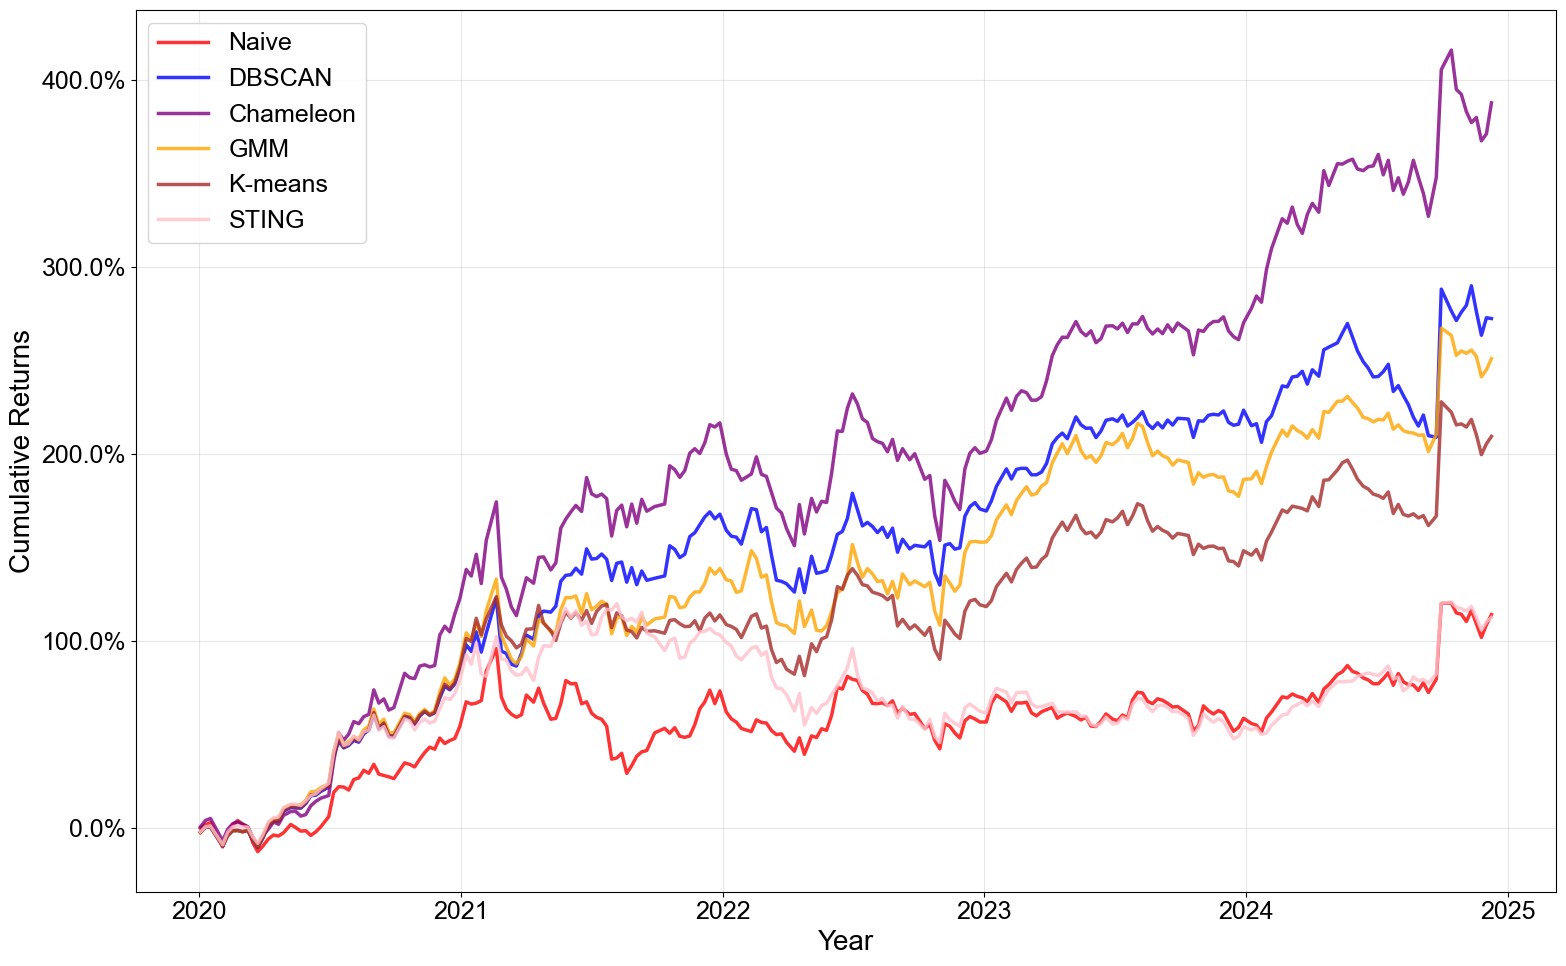

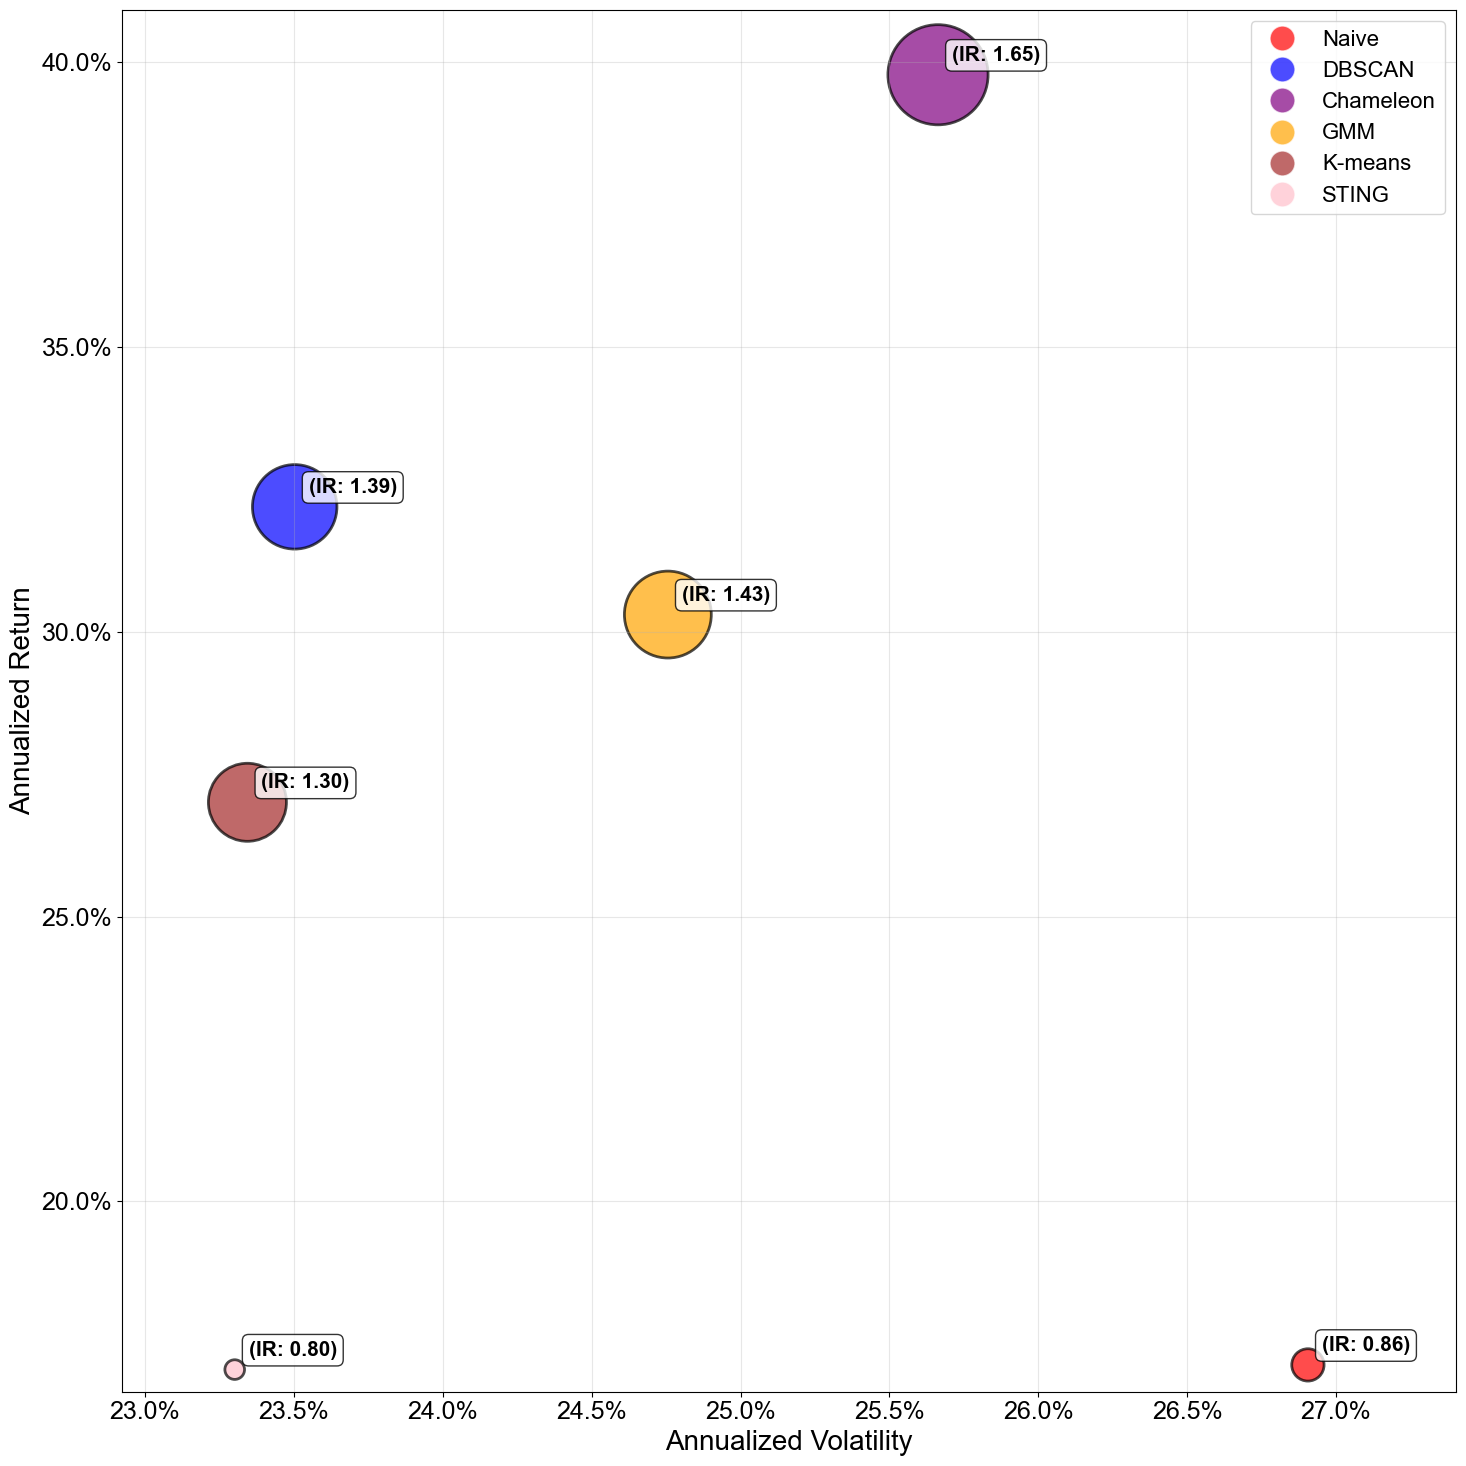


Method      Annual ReturnAnnual Vol  Information Ratio
------------------------------------------------
Naive       0.1713      0.2691      0.8594      
DBSCAN      0.3220      0.2350      1.3932      
Chameleon   0.3978      0.2566      1.6467      
GMM         0.3030      0.2476      1.4292      
K-means     0.2701      0.2334      1.3013      
STING       0.1704      0.2330      0.8017      


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 18
SAVE_DPI = plt.rcParams['savefig.dpi']

class PortfolioVisualization:
    def __init__(self):
        self.stock_data = None
        self.selected_stocks = {}
        self.daily_returns = {}
        self.daily_returns_with_dates = {}
        
    def load_stock_data(self):
        data1 = pd.read_csv('TRD_Dalyr(20150105-20200103).csv')
        data2 = pd.read_csv('TRD_Dalyr(20200106-20241213).csv')
        
        self.stock_data = pd.concat([data1, data2], ignore_index=True)
        self.stock_data['Trddt'] = pd.to_datetime(self.stock_data['Trddt'])
        self.stock_data['Year'] = self.stock_data['Trddt'].dt.year
        self.stock_data = self.stock_data[self.stock_data['Year'].isin([2020, 2021, 2022, 2023, 2024])]

    def load_selected_stocks(self):
        years = [2020, 2021, 2022, 2023, 2024]
        methods = ['Naive', 'DBSCAN', 'Chameleon', 'GMM', 'K-means', 'STING']
        
        self.selected_stocks = {method: {} for method in methods}
        for year in years:
            filename = f'{year}年选择的股票列表.csv'
            with open(filename, 'r', encoding='utf-8-sig') as f:
                reader = csv.reader(f)
                header = next(reader)

                for method in methods:
                    self.selected_stocks[method][year] = []
                header_mapping = {}
                for i, col_name in enumerate(header):
                    col_name = col_name.strip()
                    if col_name in methods:
                        header_mapping[i] = col_name

                for row in reader:
                    for col_idx, method in header_mapping.items():
                        if col_idx < len(row) and row[col_idx].strip():
                            stock_code = int(row[col_idx].strip())
                            self.selected_stocks[method][year].append(stock_code)

    
    def calculate_portfolio_daily_returns(self):

        years = [2020, 2021, 2022, 2023, 2024]
        methods = ['Naive', 'DBSCAN', 'Chameleon', 'GMM', 'K-means', 'STING']
        
        self.daily_returns = {method: [] for method in methods}
        self.daily_returns_with_dates = {method: {'dates': [], 'returns': []} for method in methods}
        
        for year in years:
            year_data = self.stock_data[self.stock_data['Year'] == year].copy()
            year_data = year_data.sort_values('Trddt')
            trading_dates = sorted(year_data['Trddt'].unique())
            
            for method in methods:
                selected_stocks = self.selected_stocks[method].get(year, [])
                
                method_daily_returns = []
                method_dates = []
                portfolio_values = []
                
                for i, date in enumerate(trading_dates):
                    date_data = year_data[year_data['Trddt'] == date]
                    
                    portfolio_prices = []
                    
                    for stock_code in selected_stocks:
                        stock_date_data = date_data[date_data['Stkcd'] == stock_code]
                        if len(stock_date_data) > 0:
                            price = stock_date_data['Clsprc'].iloc[0]
                            if not pd.isna(price) and price > 0:
                                portfolio_prices.append(price)
                    
                    if len(portfolio_prices) > 0:
                        avg_price = np.mean(portfolio_prices)
                        portfolio_values.append(avg_price)
                        
                        if len(portfolio_values) > 1:
                            daily_return = (portfolio_values[-1] / portfolio_values[-2]) - 1
                            method_daily_returns.append(daily_return)
                            method_dates.append(date)
                
                if method_daily_returns:
                    self.daily_returns[method].extend(method_daily_returns)
                    self.daily_returns_with_dates[method]['dates'].extend(method_dates)
                    self.daily_returns_with_dates[method]['returns'].extend(method_daily_returns)
    
    def plot_cumulative_returns(self):
        """绘制累积收益率图"""
        methods = ['Naive', 'DBSCAN', 'Chameleon', 'GMM', 'K-means', 'STING']
        colors = ['red', 'blue', 'purple', 'orange', 'brown', 'pink']
        line_styles = ['-', '-', '-', '-', '-', '-']
        
        plt.figure(figsize=(16, 10))    
        for i, method in enumerate(methods):
            dates = self.daily_returns_with_dates[method]['dates']
            returns = self.daily_returns_with_dates[method]['returns']
            
            if dates and returns and len(returns) > 10:
                date_series = pd.Series(returns, index=dates)
                date_series = date_series.sort_index()
                
                cumulative_returns = (1 + date_series).cumprod() - 1
                sampled_data = cumulative_returns.iloc[::5]
                
                plt.plot(sampled_data.index, sampled_data.values, 
                        label=method, color=colors[i], linewidth=2.5, 
                        linestyle=line_styles[i], markersize=4, alpha=0.8)

                final_return = cumulative_returns.iloc[-1]
                print(f"{method} Cumulative Return: {final_return*100:.2f}%")
        plt.legend(fontsize=18, loc='best', prop={'family': 'Arial', 'size': 18})
        plt.grid(True, alpha=0.3)
        
        # 格式化y轴为百分比
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
        
        plt.ylabel('Cumulative Returns', fontsize=20, family='Arial')
        plt.xlabel('Year', fontsize=20, family='Arial')
        
        # 设置坐标轴字体
        plt.xticks(fontfamily='Arial', fontsize=18)
        plt.yticks(fontfamily='Arial', fontsize=18)
        plt.tight_layout()

        plt.savefig(f'cumulative_returns_timeseries_{SAVE_DPI}dpi.png', dpi=SAVE_DPI, bbox_inches='tight', format='png')
        plt.show()
    
    def plot_risk_return_scatter(self):
        """绘制风险收益散点图"""
        methods = ['Naive', 'DBSCAN', 'Chameleon', 'GMM', 'K-means', 'STING']
        colors = ['red', 'blue', 'purple', 'orange', 'brown', 'pink']
        information_ratios_from_file = {}
        information_df = pd.read_csv('信息比率汇总.csv')
        avg_row = None
        for idx, row in information_df.iterrows():
            if 'Avg' in str(row.iloc[0]):
                avg_row = row
                break
        if avg_row is not None:
            method_mapping = {
                'Naive': 'Naive',
                'DBSCAN': 'DBSCAN',
                'Chameleon': 'Chameleon', 
                'GMM': 'GMM',
                'K-means': 'K-means',
                'STING': 'STING'
            }
            for col_name in information_df.columns[1:]:
                col_name_clean = col_name.strip()
                for key, method in method_mapping.items():
                    if key in col_name_clean or col_name_clean.startswith(key):
                        information_ratios_from_file[method] = float(avg_row[col_name])
                        break

        risks = []
        returns = []
        information_ratios = []
        valid_methods = []
        valid_colors = []
        
        for i, method in enumerate(methods):
            daily_returns = self.daily_returns[method]
            
            if daily_returns and len(daily_returns) > 30:
                returns_series = pd.Series(daily_returns)
                trading_days = len(daily_returns)
                years_period = trading_days / 252
                total_return = (1 + returns_series).prod() - 1
                annual_return = (1 + total_return) ** (1/years_period) - 1
                annual_volatility = returns_series.std() * np.sqrt(252)
                if method in information_ratios_from_file:
                    information_ratio = information_ratios_from_file[method]
                risks.append(annual_volatility)
                returns.append(annual_return)
                information_ratios.append(information_ratio)
                valid_methods.append(method)
                valid_colors.append(colors[i])

        plt.figure(figsize=(15, 15))    

        min_information = min(information_ratios) if information_ratios else 0
        max_information = max(information_ratios) if information_ratios else 1

        if max_information == min_information:
            point_sizes = [300] * len(information_ratios)
        else:

            normalized_information = [(s - min_information) / (max_information - min_information) for s in information_ratios]
            point_sizes = [200 + 5000 * ns for ns in normalized_information]
        scatter = plt.scatter(risks, returns, c=valid_colors, s=point_sizes, alpha=0.7, 
                            edgecolors='black', linewidth=2)
        
        # 添加标签
        for i, method in enumerate(valid_methods):
            plt.annotate(f'(IR: {information_ratios[i]:.2f})', 
                        (risks[i], returns[i]), 
                        xytext=(10, 10), textcoords='offset points',
                        fontsize=15, fontweight='bold', family='Arial',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        # 添加颜色图例
        legend_elements = []
        for i, method in enumerate(valid_methods):
            legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                            markerfacecolor=valid_colors[i], markersize=18, 
                                            label=method, alpha=0.7))
        
        plt.legend(handles=legend_elements, fontsize=16, loc='best', 
                  prop={'family': 'Arial', 'size': 16})
        
        plt.xlabel('Annualized Volatility', fontsize=20, family='Arial')
        plt.ylabel('Annualized Return', fontsize=20, family='Arial')
        plt.grid(True, alpha=0.3)
        plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.1%}'.format(x)))
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
        plt.xticks(fontfamily='Arial', fontsize=18)
        plt.yticks(fontfamily='Arial', fontsize=18)

        current_xlim = plt.xlim()
        x_range = current_xlim[1] - current_xlim[0]
        plt.xlim(current_xlim[0] - x_range * 0.05, current_xlim[1] + x_range * 0.08)
        current_ylim = plt.ylim()
        y_range = current_ylim[1] - current_ylim[0]
        plt.ylim(current_ylim[0] + y_range * 0.03, current_ylim[1])
        plt.tight_layout()
        plt.savefig(f'risk_return_scatter_{SAVE_DPI}dpi.png', dpi=SAVE_DPI, bbox_inches='tight', format='png')
        plt.show()
        
        print(f"\n{'Method':<12}{'Annual Return':<12}{'Annual Vol':<12}{'Information Ratio':<12}")
        print("-" * 48)
        for i, method in enumerate(valid_methods):
            print(f"{method:<12}{returns[i]:<12.4f}{risks[i]:<12.4f}{information_ratios[i]:<12.4f}")

    def run_visualization_analysis(self):
        self.load_stock_data()
        self.load_selected_stocks()
        
        # 计算收益率
        self.calculate_portfolio_daily_returns()
        self.plot_cumulative_returns()
        self.plot_risk_return_scatter()

if __name__ == "__main__":
    visualizer = PortfolioVisualization()
    visualizer.run_visualization_analysis()